# Bootstrap — Confidence Intervals for Non-Normal Distributions

**When to use bootstrap:** when the data is skewed, heavy-tailed, or when you need a confidence interval for a statistic that has no simple closed-form formula (median, quantile, standard deviation, etc.).

Two approaches are covered:
- **Part 1: CI for one group** — bootstrap distribution of the median for the control group
- **Part 2: CI for the difference** — bootstrap CI for the difference in medians between two groups

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import bootstrap
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Part 1: Dataset Overview & Motivation

## 1. Dataset Overview

In [39]:
data = pd.read_csv('data/bootstrap_data.csv')
print(f'Shape: {data.shape}')
data.head()

Shape: (1254, 2)


,value,group
0,100.719713,experimental
1,106.771525,experimental
2,106.974612,experimental
3,109.249662,experimental
4,116.230142,experimental


In [40]:
data.info()
print()
print('Group sizes:')
print(data.groupby('group').size())

<class 'pandas.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   1254 non-null   float64
 1   group   1254 non-null   str    
dtypes: float64(1), str(1)
memory usage: 19.7 KB

Group sizes:
group
control         760
experimental    494
dtype: int64


## 2. Visual Exploration

Before choosing a test, always inspect the distributions. User-level metrics are often skewed: most users concentrate on the left, with a long right tail of heavy users.

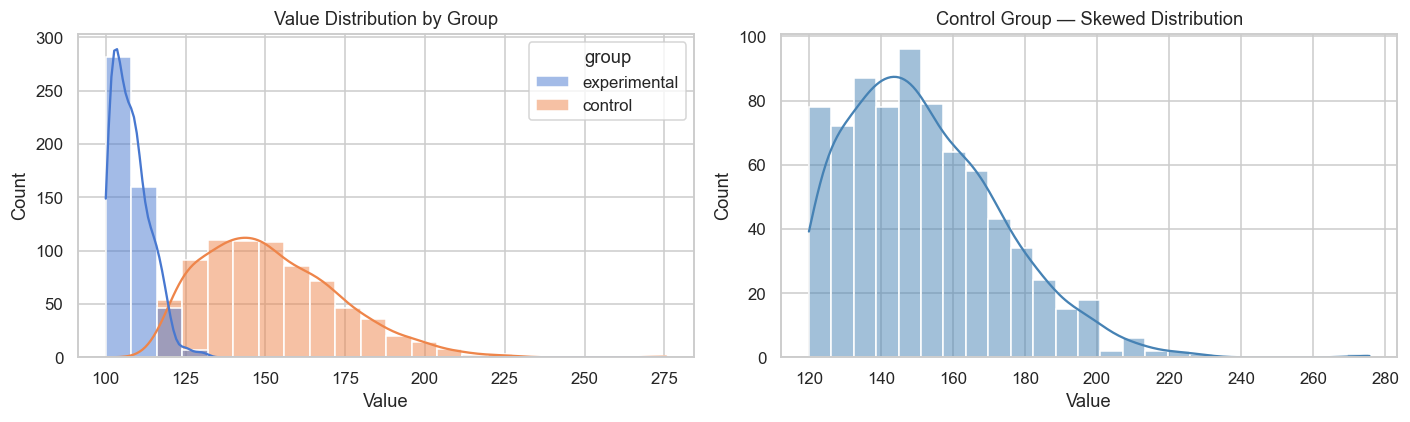

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=data, x='value', hue='group', ax=axes[0], kde=True, alpha=0.5)
axes[0].set_title('Value Distribution by Group')
axes[0].set_xlabel('Value')

sns.histplot(data=data.query('group=="control"'), x='value', ax=axes[1], kde=True, color='steelblue')
axes[1].set_title('Control Group — Skewed Distribution')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.show()

## 3. Why Not a t-test?

| Method | Problem |
|--------|---------|
| **t-test** | Compares means, not medians. Assumes normality and equal variance — violated here |
| **Mann-Whitney U** | Compares rank distributions, not medians directly. Business-unfriendly interpretation |
| **Bootstrap** | Works for any statistic (median, quantile, ratio) regardless of distribution shape |

**Key idea:** instead of repeating the experiment 10 000 times (impractical), bootstrap *resamples with replacement* from the existing sample — using internal resources to simulate the variability of the statistic.

In [42]:
data.groupby('group', as_index=False).agg({'value': 'median'}).rename(columns={'value': 'median'})

,group,median
0,control,148.832127
1,experimental,106.982597


---
## Part 2: Bootstrap CI for One Group

## 4. Manual Bootstrap

**Algorithm:**
1. Draw a resample of the same size *with replacement* from the original sample
2. Compute the statistic (median) on the resample
3. Repeat 10 000 times
4. The resulting distribution approximates the sampling distribution of the statistic
5. Take the 2.5th and 97.5th percentiles → 95% confidence interval

10 000 iterations is the industry standard for stable CI estimates.

In [43]:
control_df = data.query('group=="control"')

n_iter = 10_000
medians = []

for _ in range(n_iter):
    sample = control_df.sample(frac=1, replace=True).value
    medians.append(sample.median())

## 5. Bootstrap Distribution & Confidence Interval

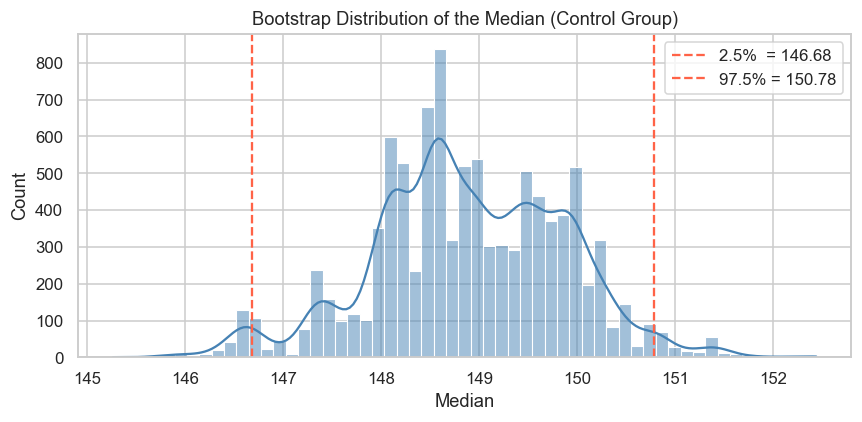

95% CI for control median: [146.68, 150.78]


In [44]:
medians_s = pd.Series(medians)
ci_low  = medians_s.quantile(0.025).round(2)
ci_high = medians_s.quantile(0.975).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(medians, kde=True, ax=ax, color='steelblue')
ax.axvline(ci_low,  color='tomato', linestyle='--', label=f'2.5%  = {ci_low}')
ax.axvline(ci_high, color='tomato', linestyle='--', label=f'97.5% = {ci_high}')
ax.set_title('Bootstrap Distribution of the Median (Control Group)')
ax.set_xlabel('Median')
ax.legend()
plt.tight_layout()
plt.show()

print(f'95% CI for control median: [{ci_low}, {ci_high}]')

## 6. Verification with `scipy.stats.bootstrap`

In [45]:
result = bootstrap((control_df.value,), np.median, n_resamples=9999, random_state=42)
print(f'scipy CI: [{result.confidence_interval.low:.2f}, {result.confidence_interval.high:.2f}]')
print(f'Standard error: {result.standard_error:.4f}')

scipy CI: [146.63, 150.78]
Standard error: 1.0033


**Part 2 Summary:**

| Method | CI low | CI high |
|--------|--------|---------|
| Manual loop | 146.68 | 150.78 |
| `scipy.stats.bootstrap` | ≈ 146.69 | ≈ 150.78 |

- Both methods agree: the 95% CI for the control group median is approximately **[146.68, 150.78]**
- If the CI for a second group does not overlap this interval, we can claim a statistically significant difference in medians

---
## Part 3: Bootstrap CI for the Difference in Medians

## 7. Bootstrap Difference in Medians

**Algorithm:**
1. Draw a resample (with replacement) from the control group → compute its median
2. Draw a resample (with replacement) from the experimental group → compute its median
3. Record the difference: `median_control − median_experimental`
4. Repeat 10 000 times
5. Build a 95% CI from the distribution of differences

If the CI **does not include 0**, the difference is statistically significant.

In [46]:
exp_df = data.query("group=='experimental'")
medians_diff = []

for _ in range(n_iter):
    sample_control = control_df.sample(frac=1, replace=True).value
    sample_exp     = exp_df.sample(frac=1, replace=True).value
    medians_diff.append(sample_control.median() - sample_exp.median())

## 8. Distribution of Differences & Confidence Interval

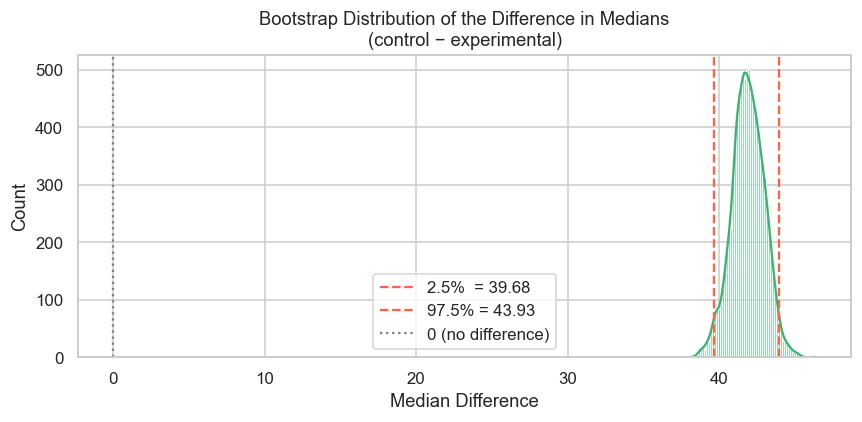

95% CI for median difference: [39.68, 43.93]


In [47]:
diff_s = pd.Series(medians_diff)
diff_low  = diff_s.quantile(0.025).round(2)
diff_high = diff_s.quantile(0.975).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(medians_diff, kde=True, ax=ax, color='mediumseagreen')
ax.axvline(diff_low,  color='tomato', linestyle='--', label=f'2.5%  = {diff_low}')
ax.axvline(diff_high, color='tomato', linestyle='--', label=f'97.5% = {diff_high}')
ax.axvline(0, color='grey', linestyle=':', label='0 (no difference)')
ax.set_title('Bootstrap Distribution of the Difference in Medians\n(control − experimental)')
ax.set_xlabel('Median Difference')
ax.legend()
plt.tight_layout()
plt.show()

print(f'95% CI for median difference: [{diff_low}, {diff_high}]')

## Conclusion

### Part 2: CI for One Group (Control)
- 95% bootstrap CI for the control group median: **[146.68, 150.78]**
- Manual loop and `scipy.stats.bootstrap` produce consistent results

### Part 3: CI for the Difference in Medians
- 95% CI for `median_control − median_experimental`: **[≈ 39.66, ≈ 43.90]**
- The entire interval is **positive** and **does not include 0** → the difference is statistically significant
- Control group median is ~40 units higher than experimental

### When to Use Bootstrap
| Use case | Why bootstrap |
|----------|---------------|
| Skewed / heavy-tailed data | No normality assumption required |
| Comparing medians or quantiles | No closed-form CI formula needed |
| Small or unequal sample sizes | Robust to group size imbalance |
| Any custom statistic | Works for mean, std, ratio, quantile, etc. |